# 05 — Gaussian blur and reduced brightness

**Question:** How do blur and brightness reduction change face verification at the original operating thresholds?

We evaluate seven conditions: original, Gaussian blur σ = 1, 2, 3 pixels, and brightness factors 0.75, 0.50, 0.25.
Each degradation starts independently from the original 160 × 160 probe crop. Reference embeddings, baseline-eligible pairs, model, and all ten baseline fold thresholds remain fixed. No new detection or threshold calibration runs.

Run in the existing project environment on the computer with the original baseline cache. See [the README](../README.md#blur-and-brightness-experiment) for setup instructions. Restart the kernel after changing source files.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "src/face_embedding.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from within your existing repository")
sys.path.insert(0, str(ROOT / "src"))
from quality_degradation import CONDITIONS, QUALITY_CONFIG, apply_condition
from quality_experiment import run_quality
from resolution_experiment import inside
from lfw_dataset import sha256

print("Project:", ROOT)
print("Python:", sys.version.split()[0])
print("Interpreter:", sys.executable)
print("Conditions:", [c["condition"] for c in CONDITIONS])

Project: /Users/dhrumil/Fall 2026/Biometrics/Evaluating Face Verification
Python: 3.13.7
Interpreter: /Users/dhrumil/Fall 2026/Biometrics/Evaluating Face Verification/.venv/bin/python
Conditions: ['original', 'blur_sigma_1', 'blur_sigma_2', 'blur_sigma_3', 'brightness_0.75', 'brightness_0.5', 'brightness_0.25']


## Run all conditions
The original control must reproduce the saved baseline. Invalid degraded embeddings abort the experiment; they do not create extra exclusions. Completed embeddings are cached, so an interrupted run can resume by rerunning this cell. Only run one process against this cache at a time.

Brightness factors scale encoded RGB values before the existing model standardization. They do not simulate camera exposure, sensor noise, shadows, or other real low-light effects. Gaussian blur uses a sampled separable kernel truncated at three standard deviations and reflected boundaries.

In [2]:
report = run_quality(ROOT)
assert report["status"] == "completed"
for name, expected in report["output_sha256"].items():
    assert sha256(ROOT / "results/metrics" / name) == expected, name
print(f"\nCompleted {len(report['conditions'])} conditions in {report['elapsed_seconds']/60:.2f} minutes")
print("Unique eligible probes:", report["unique_probes"])
print("Original embedding check maximum difference:", report["control_embedding_max_abs_difference"])

Verifying baseline results and cached crops ...


original: accuracy 99.167%, FMR 0.433%, FNMR 1.234%


blur_sigma_1: 100/4575 probes | reused 0


blur_sigma_1: 200/4575 probes | reused 0


blur_sigma_1: 300/4575 probes | reused 0


...

brightness_0.25: 4400/4575 probes | reused 0


brightness_0.25: 4500/4575 probes | reused 0


brightness_0.25: 4575/4575 probes | reused 0


brightness_0.25: accuracy 98.566%, FMR 0.433%, FNMR 2.434%



Completed 7 conditions in 6.07 minutes
Unique eligible probes: 4575
Original embedding check maximum difference: 0.0


In [3]:
labels = {"original":"Original", "blur_sigma_1":"Blur σ = 1 px", "blur_sigma_2":"Blur σ = 2 px",
          "blur_sigma_3":"Blur σ = 3 px", "brightness_0.75":"Brightness × 0.75",
          "brightness_0.5":"Brightness × 0.50", "brightness_0.25":"Brightness × 0.25"}
def results_table(rows):
    lines = ["| Condition | Accuracy | FMR | FNMR | Accuracy change (pp) |",
             "|---|---:|---:|---:|---:|"]
    for r in rows:
        lines.append(f"| {labels[r['condition']]} | {100*r['mean_accuracy']:.3f}% | "
                     f"{100*r['mean_fmr']:.3f}% | {100*r['mean_fnmr']:.3f}% | {r['delta_accuracy_pp']:+.3f} |")
    return "\n".join(lines)
display(Markdown(results_table(report["conditions"])))
for r in report["conditions"]:
    print(f"{labels[r['condition']]:22s}: {r['scored_pairs']}/{r['requested_pairs']} pairs; "
          f"false matches {r['false_matches']}; false non-matches {r['false_nonmatches']}")

| Condition | Accuracy | FMR | FNMR | Accuracy change (pp) |
|---|---:|---:|---:|---:|
| Original | 99.167% | 0.433% | 1.234% | +0.000 |
| Blur σ = 1 px | 99.117% | 0.433% | 1.334% | -0.050 |
| Blur σ = 2 px | 98.917% | 0.433% | 1.734% | -0.250 |
| Blur σ = 3 px | 97.816% | 0.533% | 3.834% | -1.350 |
| Brightness × 0.75 | 99.217% | 0.367% | 1.200% | +0.050 |
| Brightness × 0.50 | 99.200% | 0.333% | 1.267% | +0.033 |
| Brightness × 0.25 | 98.566% | 0.433% | 2.434% | -0.600 |

Original              : 5999/6000 pairs; false matches 13; false non-matches 37
Blur σ = 1 px         : 5999/6000 pairs; false matches 13; false non-matches 40
Blur σ = 2 px         : 5999/6000 pairs; false matches 13; false non-matches 52
Blur σ = 3 px         : 5999/6000 pairs; false matches 16; false non-matches 115
Brightness × 0.75     : 5999/6000 pairs; false matches 11; false non-matches 36
Brightness × 0.50     : 5999/6000 pairs; false matches 10; false non-matches 38
Brightness × 0.25     : 5999/6000 pairs; false matches 13; false non-matches 73


## Inspect the transformations
The same original crop is used for every panel. The display converts pixels to [0,1] without per-image auto-brightness adjustment, so the brightness changes stay visible. These examples explain the transformations; the metrics use all eligible pairs.

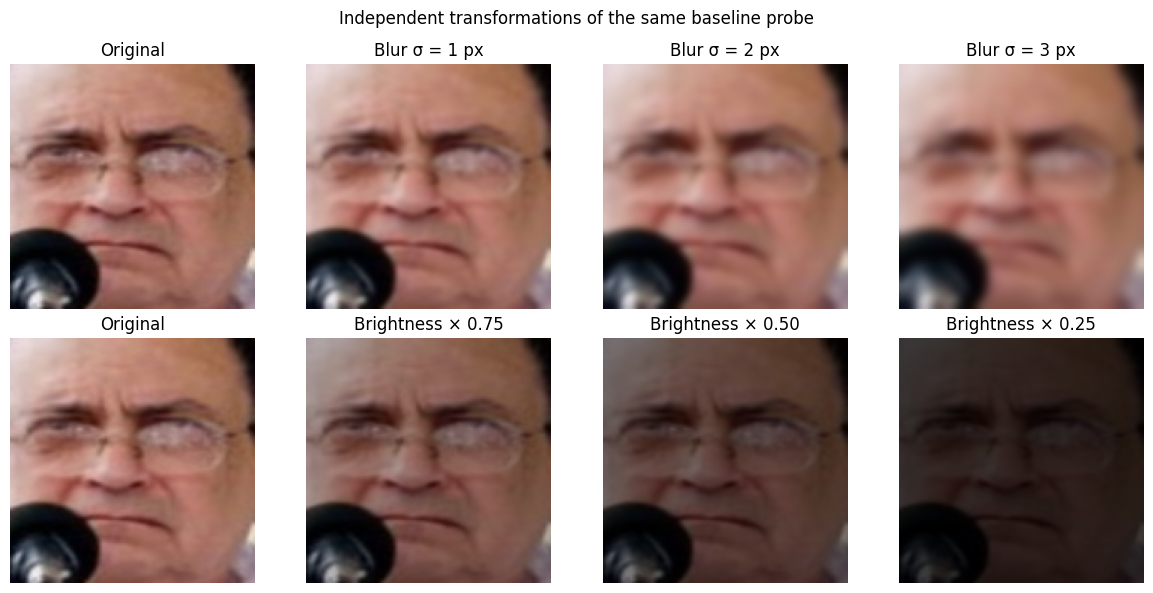

Example probe: Abel_Pacheco/Abel_Pacheco_0004.jpg


In [4]:
import csv
with (ROOT / "results/metrics/baseline_scores.csv").open(newline="", encoding="utf-8") as f:
    example_path = next(r["probe"] for r in csv.DictReader(f) if r["status"] == "scored")
records = json.loads((ROOT / "results/metrics/baseline_images.json").read_text())
record = next(r for r in records if r["path"] == example_path)
cache = inside(ROOT, report["baseline_cache"])
with np.load(inside(cache, record["payload"]), allow_pickle=False) as payload:
    original = payload["crop"].copy()
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for axes_row, family in zip(axes, ("blur", "brightness")):
    conditions = [CONDITIONS[0]] + [c for c in CONDITIONS if c["family"] == family]
    for ax, condition in zip(axes_row, conditions):
        transformed = apply_condition(original, condition)
        ax.imshow(np.clip(transformed.transpose(1,2,0)/255,0,1))
        ax.set_title(labels[condition["condition"]])
        ax.axis("off")
fig.suptitle("Independent transformations of the same baseline probe")
fig.tight_layout()
figures = ROOT / "results/figures"
figures.mkdir(parents=True, exist_ok=True)
fig.savefig(figures / "quality_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Example probe:", example_path)

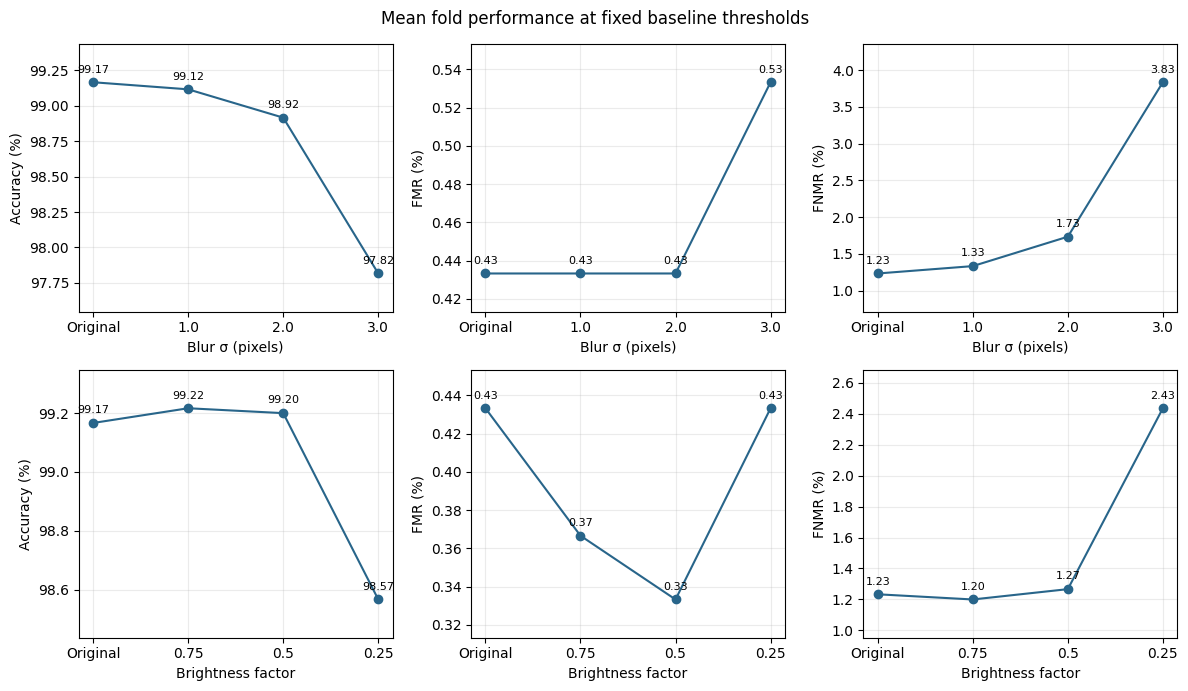

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for axes_row, family in zip(axes, ("blur", "brightness")):
    selected = [report["conditions"][0]] + [r for r in report["conditions"] if r["family"] == family]
    tick_labels = ["Original"] + [str(r["level"]) for r in selected[1:]]
    for ax, metric, title in zip(axes_row, ("accuracy", "fmr", "fnmr"), ("Accuracy", "FMR", "FNMR")):
        values = [100*r[f"mean_{metric}"] for r in selected]
        ax.plot(range(4), values, marker="o", color="#28658a")
        ax.set_xticks(range(4), tick_labels)
        ax.set_xlabel("Blur σ (pixels)" if family == "blur" else "Brightness factor")
        ax.set_ylabel(title + " (%)")
        ax.grid(alpha=.25)
        ax.margins(y=.2)
        for i, value in enumerate(values):
            ax.annotate(f"{value:.2f}", (i,value), xytext=(0,7), textcoords="offset points", ha="center", fontsize=8)
fig.suptitle("Mean fold performance at fixed baseline thresholds")
fig.tight_layout()
fig.savefig(figures / "quality_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Observations

The run started on 2026-09-11 at 12:56:57 EDT and completed in
364.024 seconds (6.07 minutes) using the unchanged Python 3.13.7 CPU
environment. Each of the six degraded conditions processed 4,575 original probe
crops, producing 27,450 fresh embeddings. No degraded embeddings were reused
on this first run. The control reused baseline embeddings and its additional
forward check had maximum absolute difference 0.0 from the cached vector.

All seven conditions scored the same 5,999 of 6,000 pairs (99.983% coverage).
The original control reproduced 99.167% mean fold accuracy, 0.433% FMR,
1.234% FNMR, 13 false matches, and 37 false non-matches. The baseline's one
excluded genuine pair remained excluded in every condition; there were no new
failures or exclusions. Reference embeddings and all ten thresholds stayed fixed.

Increasing blur reduced accuracy at each tested step: 99.117%, 98.917%, and
97.816% for sigma 1, 2, and 3. FNMR rose to 1.334%, 1.734%, and 3.834%.
FMR stayed at 0.433% through sigma 2, then rose to 0.533% at sigma 3.
False non-matches numbered 40, 52, and 115; false matches numbered 13, 13,
and 16. Thus most added errors were genuine rejections. Sigma 3 had the largest
accuracy decrease among these six new conditions: 1.350 percentage points.
Changes are computed from unrounded rates, so subtracting displayed rounded
percentages can differ by 0.001 percentage points.

Brightness results were not monotonic relative to the original control.
Retaining 75% of RGB values increased accuracy by 0.050 percentage points to
99.217%, with 11 false matches and 36 false non-matches. At 50%, accuracy was
99.200% (+0.033 percentage points), with 10 false matches and 38 false
non-matches. These conditions had 47 and 48 errors versus 50 at the control.
At 25%, accuracy fell to 98.566% (-0.600 percentage points), with 13 false
matches and 73 false non-matches; FMR was 0.433% and FNMR was 2.434%.
The small increases at 75% and 50% were retained as measured; they do not
establish that dimming generally improves verification. No significance test
or condition-specific threshold tuning was performed.

All blur and brightness conditions had higher accuracy than the earlier
20 x 20 resolution condition (89.982%). These severity scales are not matched,
so this observation applies only to the chosen settings and does not rank the
degradation types universally. Future comparisons should retain this limitation.

Visual review of the example figure showed softer glasses, eye, and mouth edges
with increasing blur. The brightness panels became darker while retaining the
original edge structure. Both rows start from the same original probe; the
display preserves absolute brightness rather than rescaling each panel. This
single probe illustrates the transforms and is not a representative sample.
The performance plots were also reviewed; their vertical axis ranges differ,
so the labeled rates and table should guide comparisons between panels.

All 6 new quality tests and all 21 earlier tests passed. The synthetic integration
test exercised frozen thresholds, pair membership, cache reuse and repair,
invalid-embedding failure, and rejection of corrupt baseline payloads. Independent
checks matched all 42,000 prediction rows, all 70 fold results, all 27,450 cached
vectors and receipts, fixed eligibility and thresholds, error counts, means,
SD/SE, and percentage-point changes. Eighteen additional real-probe forward
checks used independently computed convolutions or pixel scaling and matched
cached vectors within 1e-6. Prior baseline and resolution reports, the baseline
manifest, and all original crop/embedding payload hashes were unchanged.

All six notebook code cells completed without execution errors. No package
installation, dependency changes, model changes, or runtime fixes were needed.
Setup references were consolidated in README.md, and actual model/environment,
source, and output fingerprints are retained in the JSON report. This is a
synthetic post-crop study conditional on baseline preprocessing success; RGB
scaling does not simulate camera exposure or sensor noise, and degraded-input
face detection was not measured. Training-data overlap with LFW remains unaudited.


## Generate the experiment-log entry
Copy the generated text below into `docs/experiment_log.md` and replace the observation placeholder. Add the measured table and a link to the blur and brightness setup section to the README. Preserve the baseline and resolution results.

In [6]:
control = report["conditions"][0]
log_entry = (
    "## Stage 007 — Gaussian blur and reduced brightness\n\n"
    f"Run timestamp (UTC): {report['run_at_utc']}\n\n"
    "### Goal and method\n"
    "Evaluate independent Gaussian blur (σ = 1, 2, 3 pixels) and encoded RGB brightness scaling "
    "(0.75, 0.50, 0.25) on original probe crops. Keep original references, the model, eligible "
    "pairs, and ten baseline fold thresholds fixed. No detection or threshold recalibration on degraded images.\n\n"
    "### Results\n\n" + results_table(report["conditions"]) + "\n\n"
    f"Every condition scored {control['scored_pairs']}/{control['requested_pairs']} pairs; "
    f"{control['excluded_pairs']} baseline exclusion(s) retained. Original control reproduced the baseline. "
    f"Run completed in {report['elapsed_seconds']/60:.2f} minutes (cache reuse is recorded in the summary).\n\n"
    "### Observations and problems encountered\n"
    "[Replace with actual observations and any failures/fixes from this run.]\n\n"
    "### Limitations\n"
    "Synthetic post-crop transformations do not reproduce all real camera effects. Brightness scaling "
    "does not simulate exposure or added sensor noise. Rates are conditional on baseline preprocessing "
    "successes. Different degradation scales are not severity-matched; comparisons apply to these "
    "tested settings. Fold SD/SE are descriptive.\n\n"
    "### Next step\n"
    "Inspect score distributions and ROC/DET curves, retaining the fixed-threshold results as the "
    "primary operational comparison.\n"
)
print(log_entry)

## Stage 007 — Gaussian blur and reduced brightness

Run timestamp (UTC): 2026-09-11T16:56:57.204309+00:00

### Goal and method
Evaluate independent Gaussian blur (σ = 1, 2, 3 pixels) and encoded RGB brightness scaling (0.75, 0.50, 0.25) on original probe crops. Keep original references, the model, eligible pairs, and ten baseline fold thresholds fixed. No detection or threshold recalibration on degraded images.

### Results

| Condition | Accuracy | FMR | FNMR | Accuracy change (pp) |
|---|---:|---:|---:|---:|
| Original | 99.167% | 0.433% | 1.234% | +0.000 |
| Blur σ = 1 px | 99.117% | 0.433% | 1.334% | -0.050 |
| Blur σ = 2 px | 98.917% | 0.433% | 1.734% | -0.250 |
| Blur σ = 3 px | 97.816% | 0.533% | 3.834% | -1.350 |
| Brightness × 0.75 | 99.217% | 0.367% | 1.200% | +0.050 |
| Brightness × 0.50 | 99.200% | 0.333% | 1.267% | +0.033 |
| Brightness × 0.25 | 98.566% | 0.433% | 2.434% | -0.600 |

Every condition scored 5999/6000 pairs; 1 baseline exclusion(s) retained. Original control